# تدريب ومقارنة نماذج التعلم غير الأشرافي (Unsupervised Model Training)

## مقدمة
في هذا الملف، سنقوم بتدريب نموذجين مشهورين في اكتشاف الشذوذ (Anomaly Detection):
1. **Isolation Forest (iForest):** تعتمد على فكرة أن الشواذ يسهل عزلها عن بقية البيانات.
2. **Local Outlier Factor (LOF):** تعتمد على كثافة البيانات المحلية لمقارنة كل نقطة بجيرانها.

سنقوم بالتدريب على البيانات السليمة فقط (Class 0) كما هو مطلوب.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import os

# تحميل البيانات وتجهيزها (تكرار سريع للخطوات السابقة لضمان استقلالية الملف)
df = pd.read_csv("../data/creditcard.csv")
normal_data = df[df['Class'] == 0]
fraud_data = df[df['Class'] == 1]

X_train_normal, X_test_normal = train_test_split(normal_data.drop('Class', axis=1), test_size=0.2, random_state=42)
X_test = pd.concat([X_test_normal, fraud_data.drop('Class', axis=1)])
y_test = np.concatenate([np.zeros(len(X_test_normal)), np.ones(len(fraud_data))])

# بناء الـ Pipeline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

## 1. تدريب نموذج Isolation Forest
يعتبر هذا النموذج من أقوى النماذج لاكتشاف الاحتيال في البيانات الضخمة.

--- Isolation Forest Results ---
              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98     56863
         1.0       0.16      0.84      0.26       492

    accuracy                           0.96     57355
   macro avg       0.58      0.90      0.62     57355
weighted avg       0.99      0.96      0.97     57355



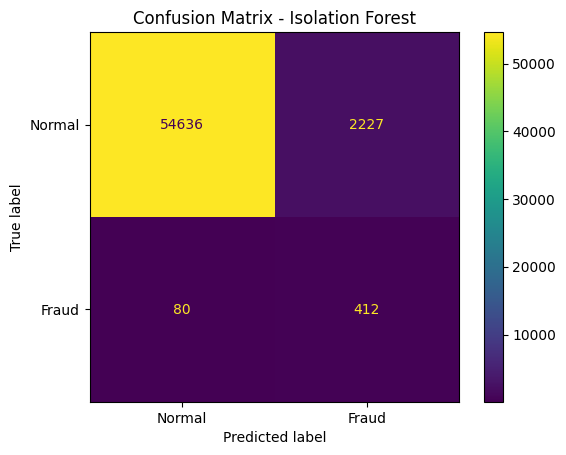

In [10]:
# نسبة التلوث المتوقعة (Outliers fraction)
outlier_fraction = len(fraud_data) / len(normal_data)

iforest = IsolationForest(
    n_estimators=100, 
    max_samples='auto', 
    contamination='auto', 
    random_state=42, 
    verbose=0
)

iforest.fit(X_train_scaled)

# التنبؤ (Isolation Forest يعيد -1 للشواذ و 1 للبيانات الطبيعية)
y_pred_iforest = iforest.predict(X_test_scaled)
y_pred_iforest = [1 if x == -1 else 0 for x in y_pred_iforest]

print("--- Isolation Forest Results ---")
print(classification_report(y_test, y_pred_iforest))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# حساب مصفوفة الالتباس
cm = confusion_matrix(y_test, y_pred_iforest)

# عرض المخطط
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - Isolation Forest")
plt.show()


## 2. تدريب نموذج Local Outlier Factor (LOF)
سنستخدم وضع `novelty=True` لنتمكن من استخدامه للتنبؤ على بيانات جديدة (خارج مجموعة التدريب).

In [5]:
lof = LocalOutlierFactor(
    n_neighbors=20, 
    algorithm='auto', 
    leaf_size=30, 
    metric='minkowski', 
    p=2, 
    contamination=0.01, 
    novelty=True
)

lof.fit(X_train_scaled)

# التنبؤ
y_pred_lof = lof.predict(X_test_scaled)
y_pred_lof = [1 if x == -1 else 0 for x in y_pred_lof]

print("--- Local Outlier Factor Results ---")
print(classification_report(y_test, y_pred_lof))

--- Local Outlier Factor Results ---
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     56863
         1.0       0.10      0.13      0.11       492

    accuracy                           0.98     57355
   macro avg       0.55      0.56      0.55     57355
weighted avg       0.98      0.98      0.98     57355



## 3. المقارنة واختيار النموذج الأفضل
سنقارن بين النموذجين بناءً على F1-Score و Recall (لأن اكتشاف الاحتيال يتطلب Recall عالي).

In [11]:
f1_iforest = f1_score(y_test, y_pred_iforest)
f1_lof = f1_score(y_test, y_pred_lof)

print(f"F1-Score for Isolation Forest: {f1_iforest:.4f}")
print(f"F1-Score for LOF: {f1_lof:.4f}")

# حفظ النموذج الأفضل (بافتراض Isolation Forest عادة ما يكون أفضل في هذه البيانات)
best_model_pipeline = Pipeline([
    ('scaler', scaler),
    ('model', iforest)
])

os.makedirs('../models', exist_ok=True)
joblib.dump(best_model_pipeline, '../models/best_model.pkl')
print("تم حفظ النموذج الأفضل بنجاح في models/best_model.pkl")

F1-Score for Isolation Forest: 0.2632
F1-Score for LOF: 0.1116
تم حفظ النموذج الأفضل بنجاح في models/best_model.pkl
